<a href="https://colab.research.google.com/github/harshikala/AI_Engineer_Journey/blob/main/MatplotlibSeaborn__Day5_Part1_Harshi_Kala.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Exercise 1: Employee Salary Analysis

In [ ]:
np.random.seed(1)
n = 50
df1 = pd.DataFrame({
    'Employee_ID': range(1, n+1),
    'Name': [f'Emp{i}' for i in range(1, n+1)],
    'Department': np.random.choice(['HR','IT','Finance','Sales','Marketing'], n),
    'Age': np.random.randint(22, 60, n),
    'Experience': np.random.choice(list(range(0,30)) + [np.nan]*3, n),
    'Salary': np.random.randint(20000, 100000, n),
    'Gender': np.random.choice(['M','F'], n)
})
df1.to_csv('employees.csv', index=False)

In [ ]:
salary_arr = np.array(df1['Salary'])
print(salary_arr.mean())
print(salary_arr.max(), salary_arr.min())
increased_salary = salary_arr * 1.08
above_avg = df1[df1['Salary'] > salary_arr.mean()]

62752.56
98843 24509


In [ ]:
df1 = pd.read_csv('employees.csv')
print(df1.head())
print(df1.tail())
print(df1.isnull().sum())
df1['Experience'] = df1['Experience'].fillna(df1['Experience'].mean())
dept_group = df1.groupby('Department')
print(dept_group['Salary'].mean())
df1_sorted = df1.sort_values('Salary')
exp_gt5 = df1[df1['Experience'] > 5]

   Employee_ID  Name Department  Age  Experience  Salary Gender
0            1  Emp1      Sales   40        20.0   98843      F
1            2  Emp2  Marketing   37         NaN   51881      F
2            3  Emp3         HR   22         7.0   28642      F
3            4  Emp4         IT   26         4.0   34535      M
4            5  Emp5      Sales   47        18.0   48469      M
    Employee_ID   Name Department  Age  Experience  Salary Gender
45           46  Emp46  Marketing   29        13.0   95023      M
46           47  Emp47    Finance   35        20.0   87230      F
47           48  Emp48  Marketing   30         6.0   47534      M
48           49  Emp49         HR   33        13.0   50195      F
49           50  Emp50      Sales   34        15.0   61351      M
Employee_ID    0
Name           0
Department     0
Age            0
Experience     7
Salary         0
Gender         0
dtype: int64
Department
Finance      60374.166667
HR           66108.000000
IT           53574.857143

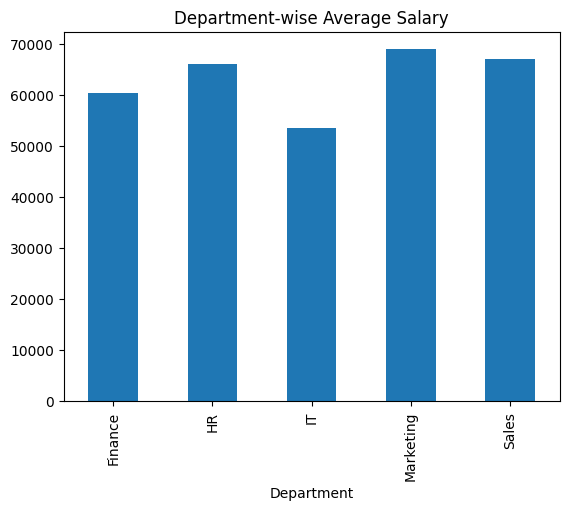

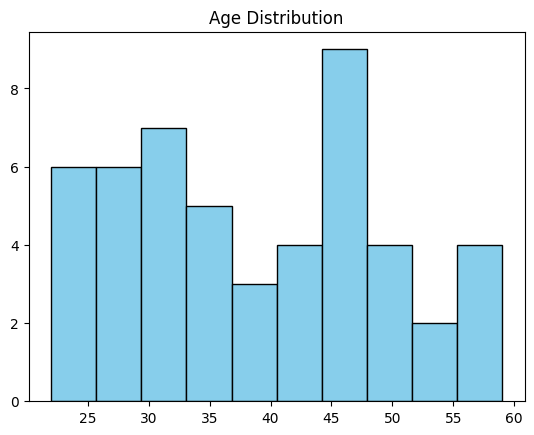

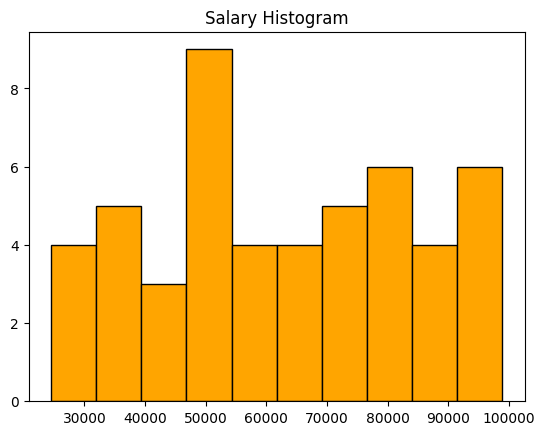

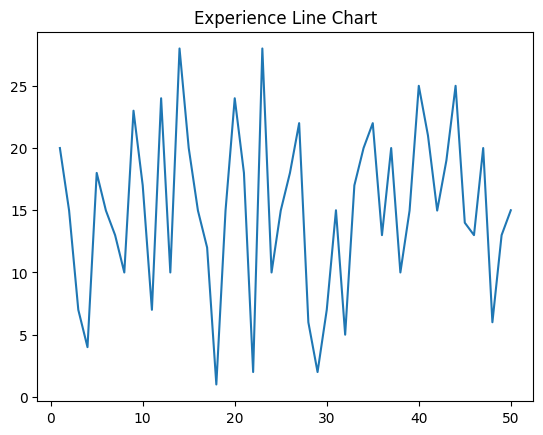

In [ ]:
dept_group['Salary'].mean().plot(kind='bar')
plt.title('Department-wise Average Salary')
plt.show()

plt.hist(df1['Age'], bins=10, color='skyblue', edgecolor='black')
plt.title('Age Distribution')
plt.show()

plt.hist(df1['Salary'], bins=10, color='orange', edgecolor='black')
plt.title('Salary Histogram')
plt.show()

plt.plot(df1['Employee_ID'], df1['Experience'])
plt.title('Experience Line Chart')
plt.show()

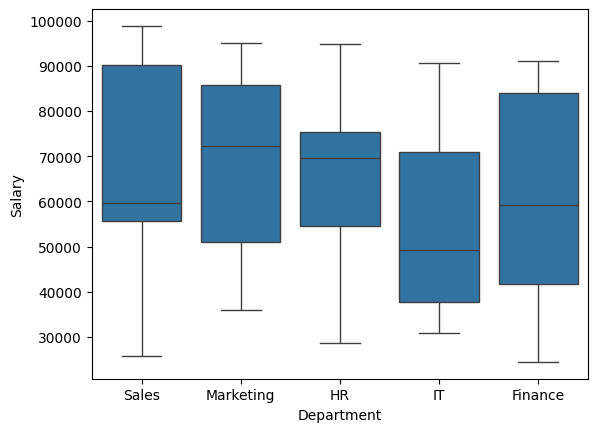

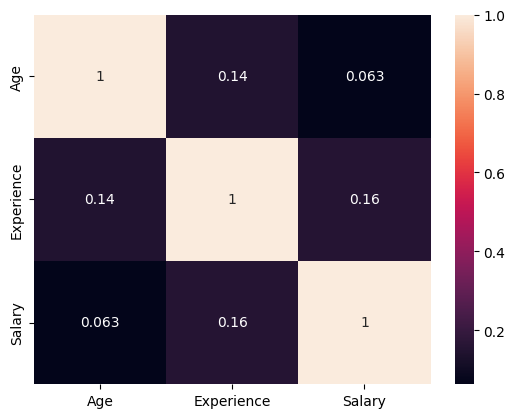

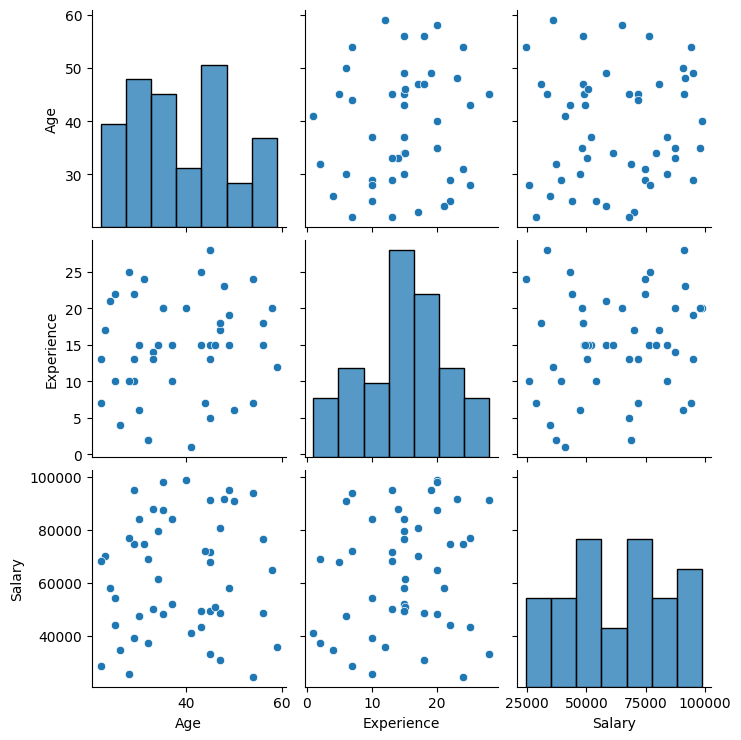

In [ ]:
sns.boxplot(x='Department', y='Salary', data=df1)
plt.show()

sns.heatmap(df1[['Age','Experience','Salary']].corr(), annot=True)
plt.show()

sns.pairplot(df1[['Age','Experience','Salary']])
plt.show()

### Exercise 2: Student Performance Analytics

In [ ]:
np.random.seed(2)
n = 50
df2 = pd.DataFrame({
    'Student_ID': range(1, n+1),
    'Name': [f'Student{i}' for i in range(1, n+1)],
    'Maths': np.random.randint(30, 100, n),
    'Science': np.random.randint(30, 100, n),
    'English': np.random.randint(30, 100, n),
    'Attendance': np.random.randint(50, 100, n),
    'Gender': np.random.choice(['M','F'], n)
})

In [ ]:
total_marks = df2[['Maths','Science','English']].to_numpy().sum(axis=1)
average_marks = df2[['Maths','Science','English']].to_numpy().mean(axis=1)
highest_scorer = df2.loc[total_marks.argmax(), 'Name']
lowest_scorer = df2.loc[total_marks.argmin(), 'Name']
grace_marks = df2[['Maths','Science','English']].to_numpy() + 5

In [ ]:
df2['Total'] = total_marks
df2['Average'] = average_marks
df2['Grade'] = pd.cut(df2['Average'], bins=[0,40,60,75,90,100], labels=['F','D','C','B','A'])
df2['Pass/Fail'] = np.where(df2['Average'] >= 40, 'Pass', 'Fail')
df2['Rank'] = df2['Total'].rank(ascending=False)
above_90 = df2[df2['Average'] > 90]
subject_avg = df2[['Maths','Science','English']].mean()

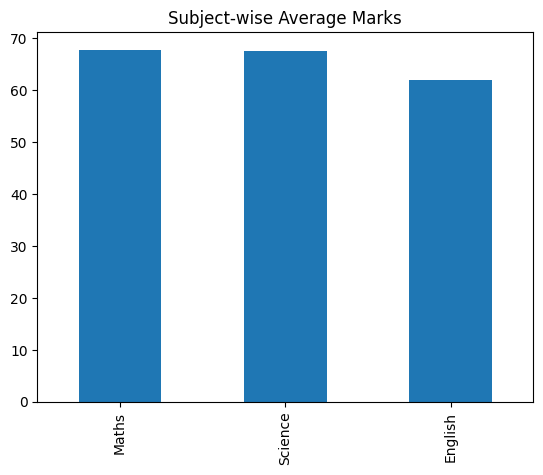

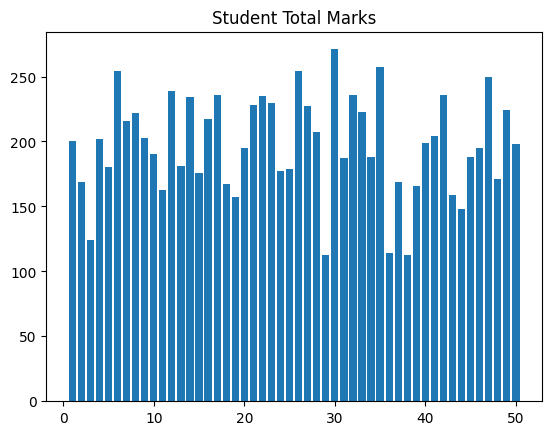

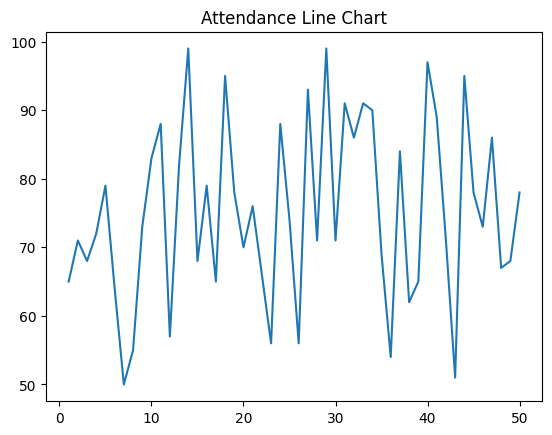

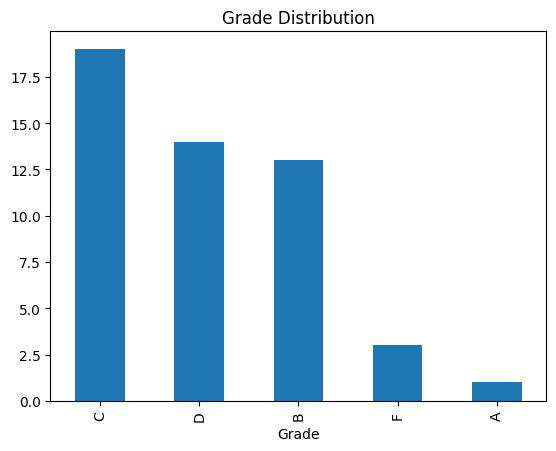

In [ ]:
subject_avg.plot(kind='bar')
plt.title('Subject-wise Average Marks')
plt.show()

plt.bar(df2['Student_ID'], df2['Total'])
plt.title('Student Total Marks')
plt.show()

plt.plot(df2['Student_ID'], df2['Attendance'])
plt.title('Attendance Line Chart')
plt.show()

df2['Grade'].value_counts().plot(kind='bar')
plt.title('Grade Distribution')
plt.show()

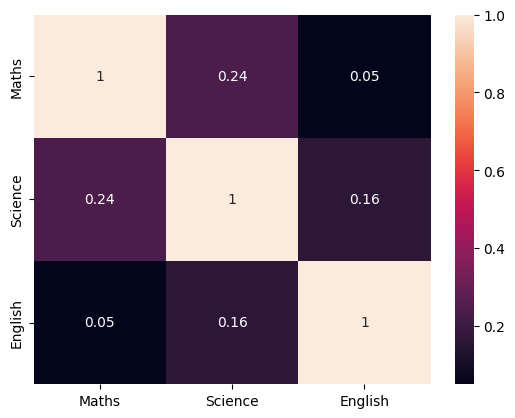

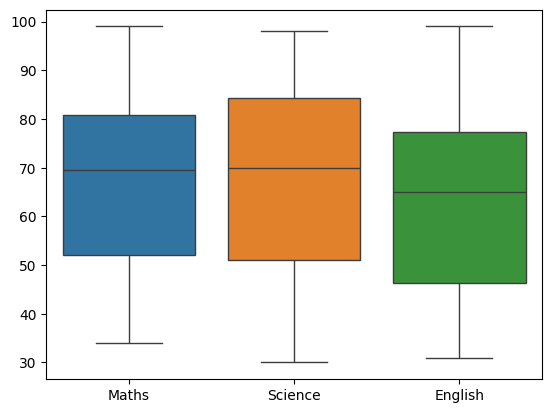

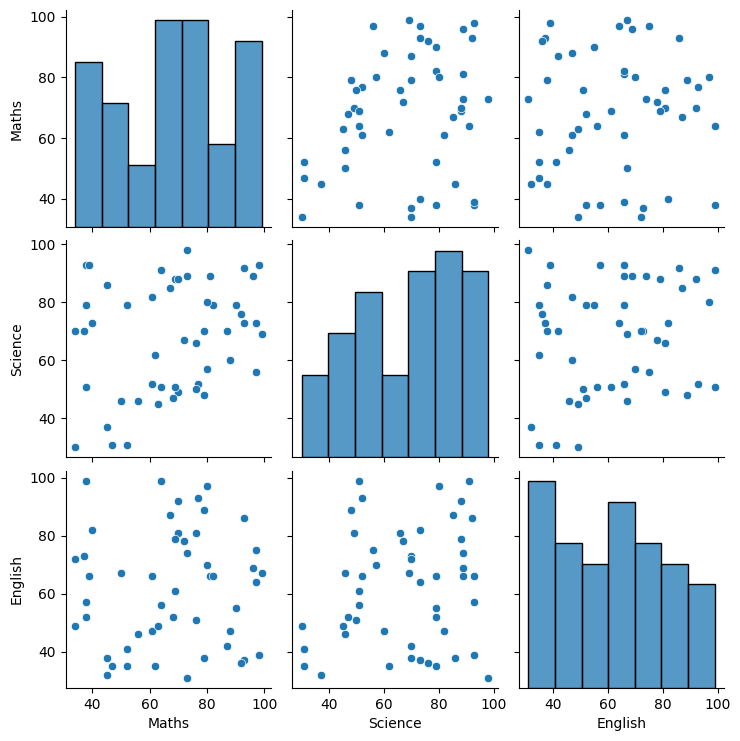

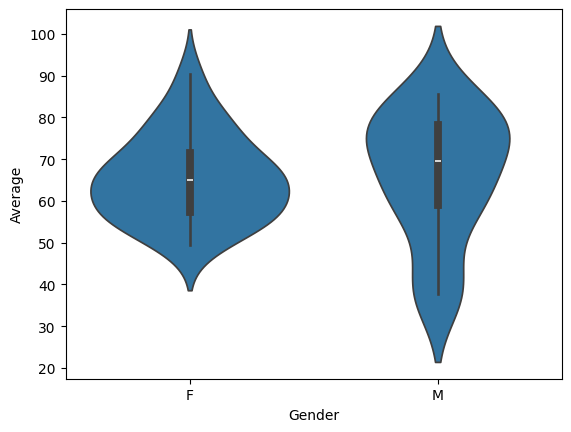

In [ ]:
sns.heatmap(df2[['Maths','Science','English']].corr(), annot=True)
plt.show()

sns.boxplot(data=df2[['Maths','Science','English']])
plt.show()

sns.pairplot(df2[['Maths','Science','English']])
plt.show()

sns.violinplot(x='Gender', y='Average', data=df2)
plt.show()

### Exercise 3: Retail Store Sales

In [ ]:
np.random.seed(3)
n = 100
df3 = pd.DataFrame({
    'Product': np.random.choice(['ProdA','ProdB','ProdC','ProdD'], n),
    'Category': np.random.choice(['Electronics','Clothing','Grocery','Furniture'], n),
    'Sales': np.random.randint(1000, 50000, n),
    'Quantity': np.random.randint(1, 100, n),
    'Region': np.random.choice(['North','South','East','West'], n),
    'Month': np.random.randint(1, 13, n)
})

In [ ]:
total_sales = df3['Sales'].to_numpy().sum()
monthly_avg = df3.groupby('Month')['Sales'].mean()
best_selling = df3.groupby('Product')['Quantity'].sum().idxmax()
monthly_growth = monthly_avg.pct_change()

In [ ]:
region_sales = df3.groupby('Region')['Sales'].sum()
product_sales = df3.groupby('Product')['Sales'].sum()
top_category = df3.groupby('Category')['Sales'].sum().idxmax()
pivot = df3.pivot_table(values='Sales', index='Region', columns='Category', aggfunc='sum')
monthly_report = df3.groupby('Month')['Sales'].sum()

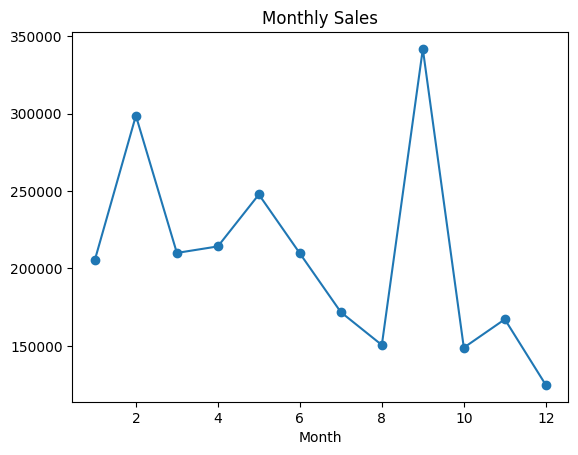

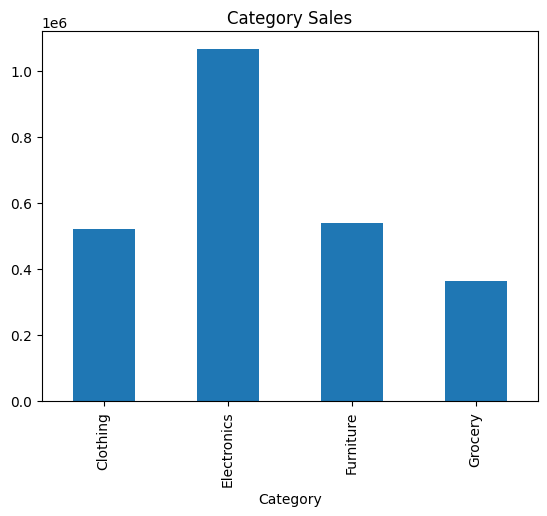

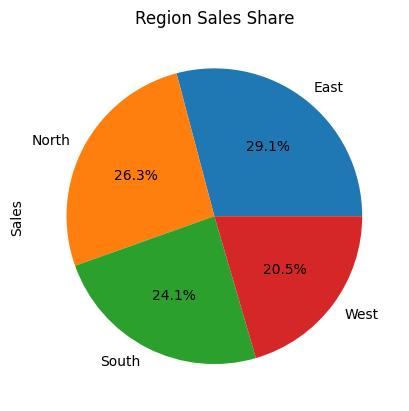

In [ ]:
monthly_report.plot(kind='line', marker='o')
plt.title('Monthly Sales')
plt.show()

df3.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title('Category Sales')
plt.show()

region_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Region Sales Share')
plt.show()

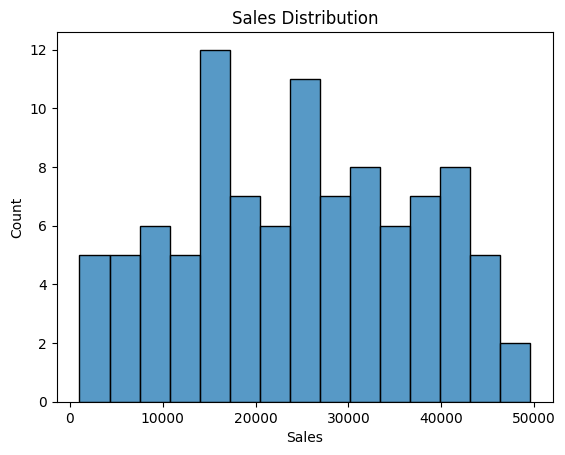

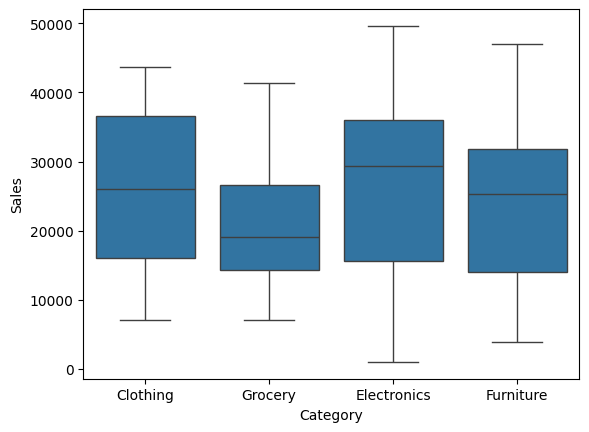

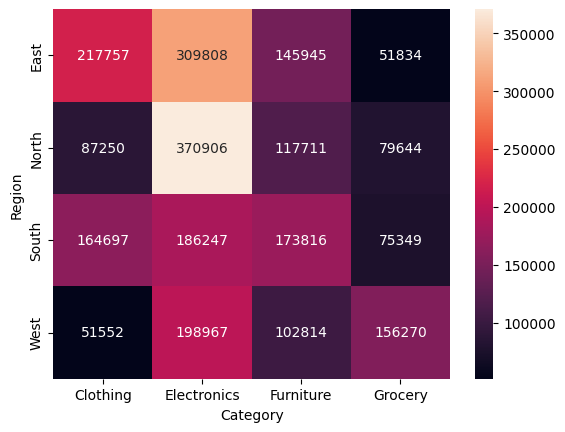

In [ ]:
sns.histplot(df3['Sales'], bins=15)
plt.title('Sales Distribution')
plt.show()

sns.boxplot(x='Category', y='Sales', data=df3)
plt.show()

sns.heatmap(pivot, annot=True, fmt='.0f')
plt.show()

### Exercise 4: Banking Transactions

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(4)
n = 80
df4 = pd.DataFrame({
    'Customer_ID': range(1, n+1),
    'Branch': np.random.choice(['BranchA','BranchB','BranchC'], n),
    'Deposit': np.random.randint(1000, 100000, n),
    'Withdrawal': np.random.randint(500, 80000, n),
    'Balance': np.random.randint(1000, 200000, n),
    'Transaction_Type': np.random.choice(['Cash','Online','Cheque'], n)
})

In [ ]:
total_deposit = df4['Deposit'].to_numpy().sum()
total_withdrawal = df4['Withdrawal'].to_numpy().sum()
avg_balance = df4['Balance'].to_numpy().mean()

In [ ]:
branch_balance = df4.groupby('Branch')['Balance'].mean()
highest_balance = df4['Balance'].max()
above_1lakh = df4[df4['Balance'] > 100000]
transaction_summary = df4.groupby('Transaction_Type')[['Deposit','Withdrawal']].sum()

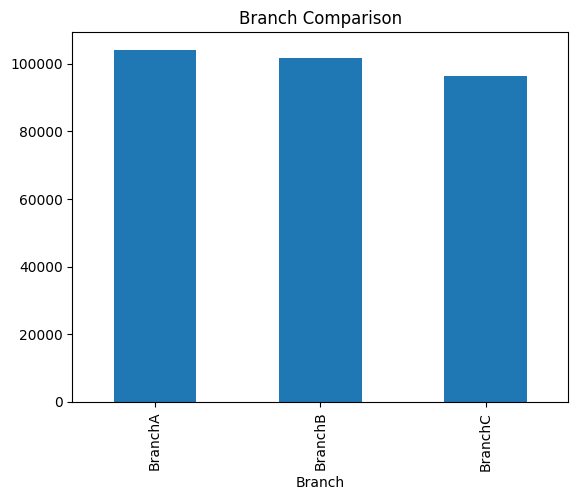

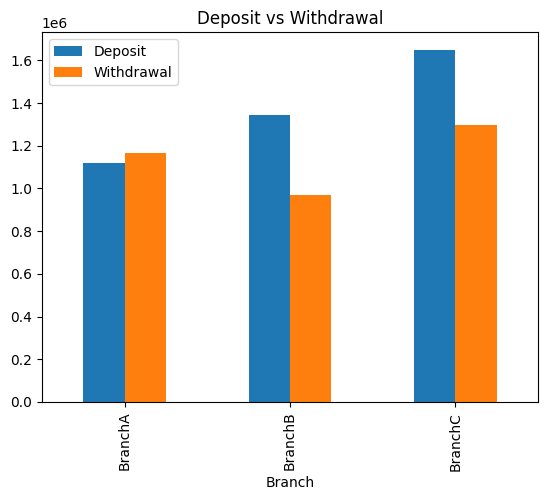

In [ ]:
branch_balance.plot(kind='bar')
plt.title('Branch Comparison')
plt.show()

df4.groupby('Branch')[['Deposit','Withdrawal']].sum().plot(kind='bar')
plt.title('Deposit vs Withdrawal')
plt.show()

In [ ]:
import seaborn as sns

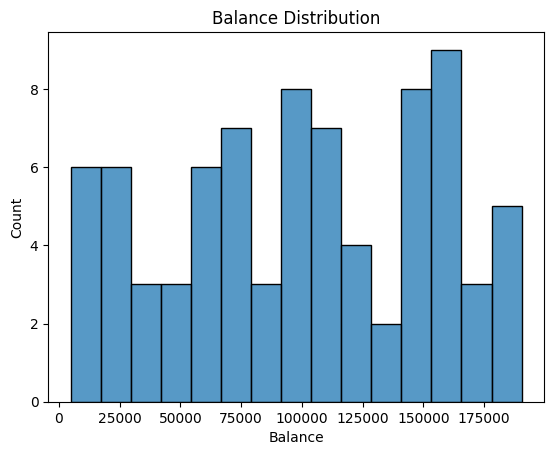

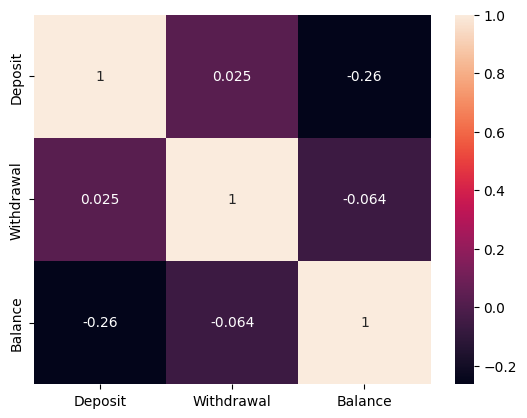

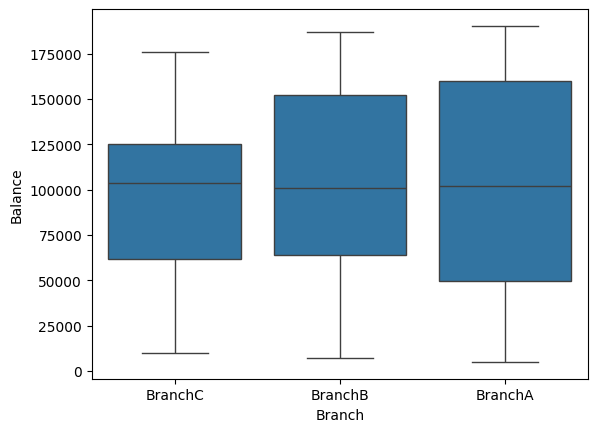

In [ ]:
sns.histplot(df4['Balance'], bins=15)
plt.title('Balance Distribution')
plt.show()

sns.heatmap(df4[['Deposit','Withdrawal','Balance']].corr(), annot=True)
plt.show()

sns.boxplot(x='Branch', y='Balance', data=df4)
plt.show()

### Exercise 5: Hospital Patient Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
np.random.seed(5)
n = 60
df5 = pd.DataFrame({
    'Patient_ID': range(1, n+1),
    'Age': np.random.randint(1, 90, n),
    'Gender': np.random.choice(['M','F'], n),
    'Temperature': np.round(np.random.uniform(97, 104, n), 1),
    'Blood_Pressure': np.random.randint(90, 180, n),
    'Disease': np.random.choice(['Flu','Diabetes','Fever','Cardiac','Covid'], n),
    'Admission_Days': np.random.randint(1, 15, n)
})

In [ ]:
avg_temp = df5['Temperature'].to_numpy().mean()
max_temp = df5['Temperature'].to_numpy().max()
min_bp = df5['Blood_Pressure'].to_numpy().min()

In [ ]:
elderly = df5[df5['Age'] > 60]
disease_count = df5['Disease'].value_counts()
avg_admission = df5.groupby('Disease')['Admission_Days'].mean()
print(df5.isnull().sum())

Patient_ID        0
Age               0
Gender            0
Temperature       0
Blood_Pressure    0
Disease           0
Admission_Days    0
dtype: int64


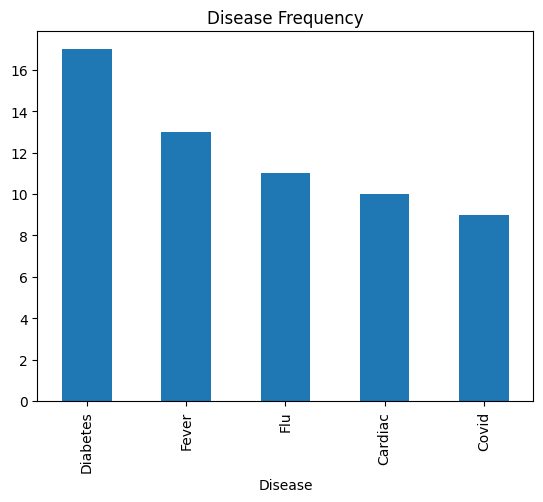

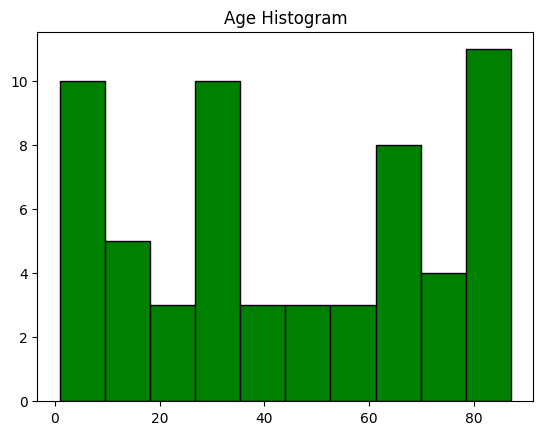

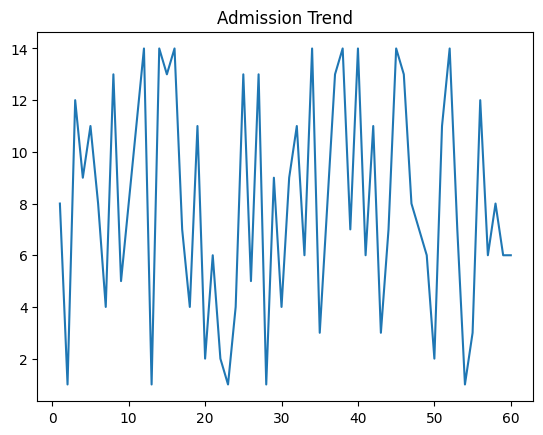

In [ ]:
disease_count.plot(kind='bar')
plt.title('Disease Frequency')
plt.show()

plt.hist(df5['Age'], bins=10, color='green', edgecolor='black')
plt.title('Age Histogram')
plt.show()

plt.plot(df5['Patient_ID'], df5['Admission_Days'])
plt.title('Admission Trend')
plt.show()

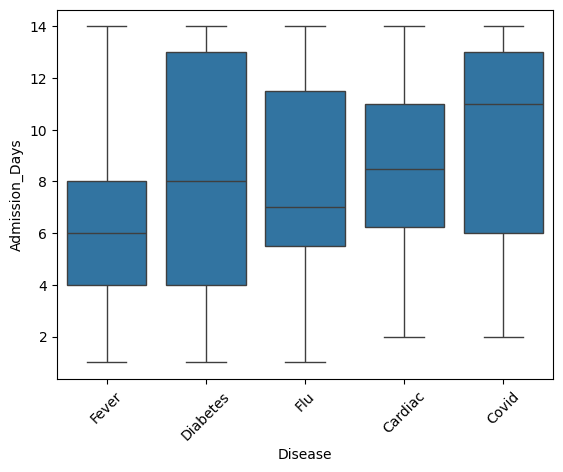

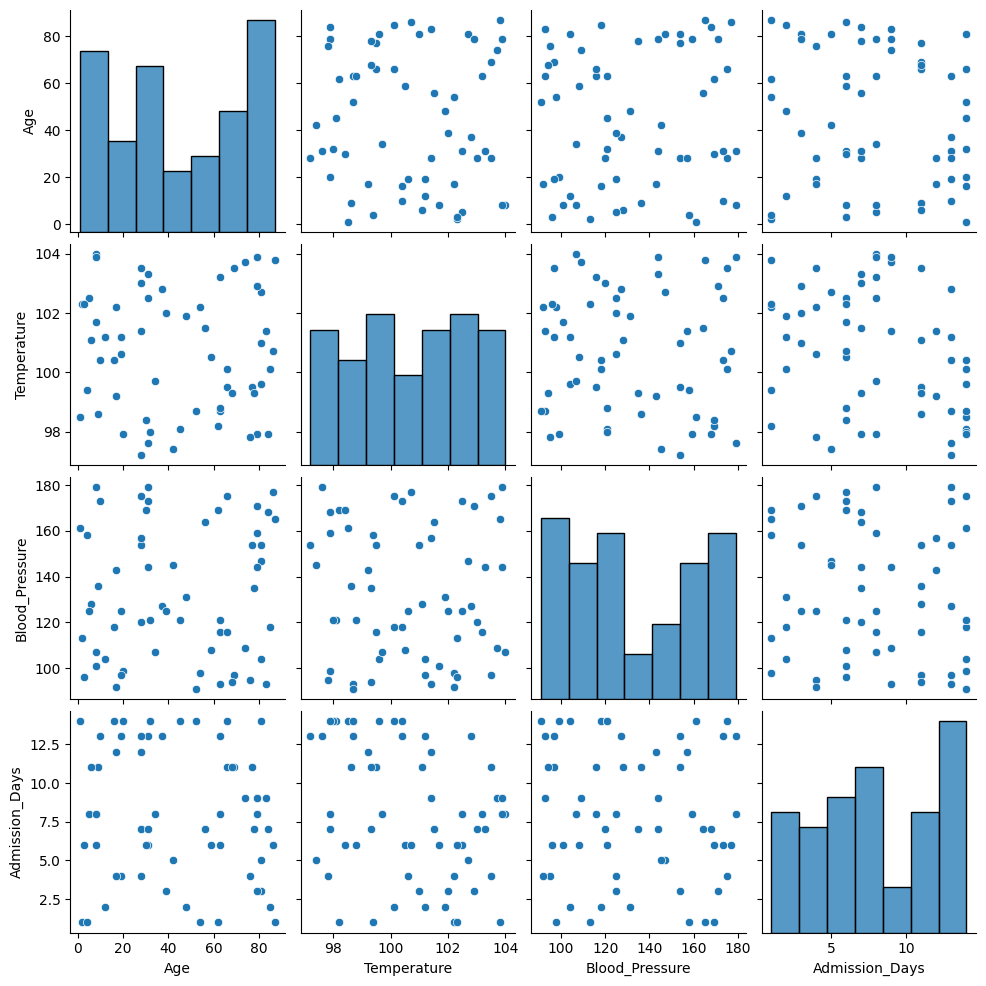

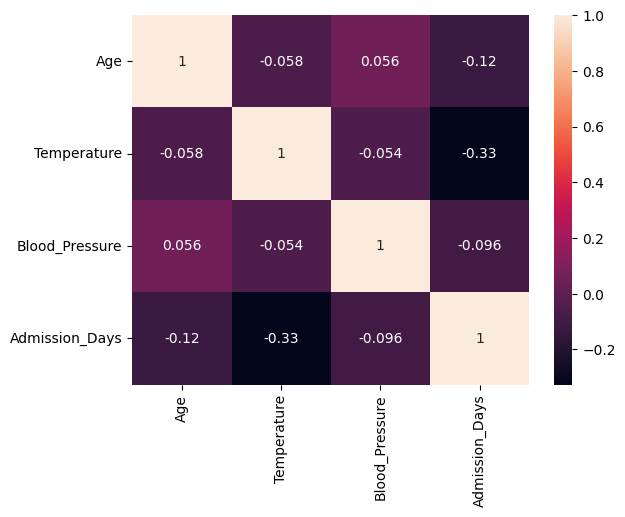

In [ ]:
sns.boxplot(x='Disease', y='Admission_Days', data=df5)
plt.xticks(rotation=45)
plt.show()

sns.pairplot(df5[['Age','Temperature','Blood_Pressure','Admission_Days']])
plt.show()

sns.heatmap(df5[['Age','Temperature','Blood_Pressure','Admission_Days']].corr(), annot=True)
plt.show()

### Exercise 6: E-commerce Orders

In [ ]:
np.random.seed(6)
n = 100
df6 = pd.DataFrame({
    'Order_ID': range(1, n+1),
    'Customer': np.random.choice([f'Cust{i}' for i in range(1,21)], n),
    'Product': np.random.choice(['ProdA','ProdB','ProdC','ProdD'], n),
    'Quantity': np.random.randint(1, 10, n),
    'Price': np.random.randint(100, 5000, n),
    'Discount': np.random.randint(0, 30, n),
    'Delivery_Days': np.random.randint(1, 10, n)
})

In [ ]:
order_value = df6['Quantity'].to_numpy() * df6['Price'].to_numpy() * (1 - df6['Discount'].to_numpy()/100)
total_revenue = order_value.sum()
avg_delivery = df6['Delivery_Days'].to_numpy().mean()

In [ ]:
df6['Order_Value'] = order_value
top_customers = df6.groupby('Customer')['Order_Value'].sum().sort_values(ascending=False).head(5)
top_products = df6.groupby('Product')['Order_Value'].sum().sort_values(ascending=False)
monthly_report = df6.groupby('Product')['Order_Value'].sum()
highest_order = df6['Order_Value'].max()

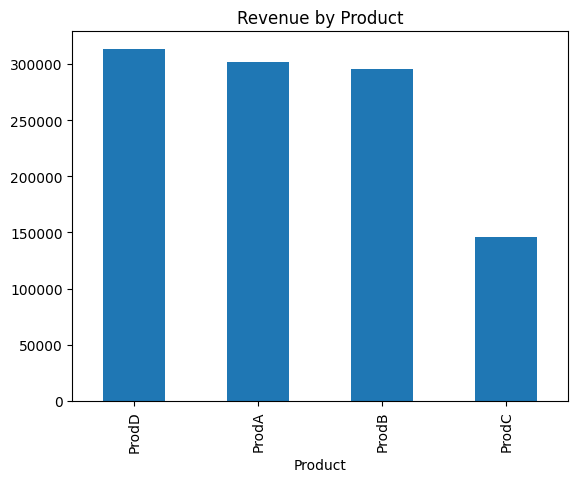

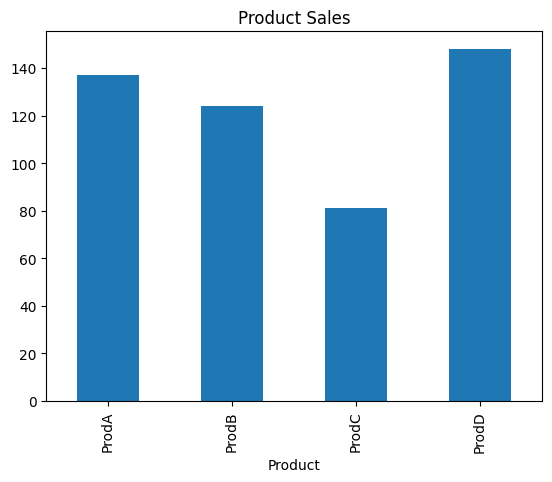

In [ ]:
top_products.plot(kind='bar')
plt.title('Revenue by Product')
plt.show()

df6.groupby('Product')['Quantity'].sum().plot(kind='bar')
plt.title('Product Sales')
plt.show()

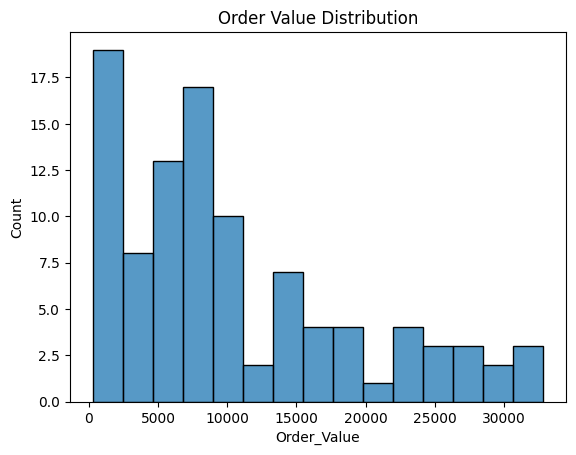

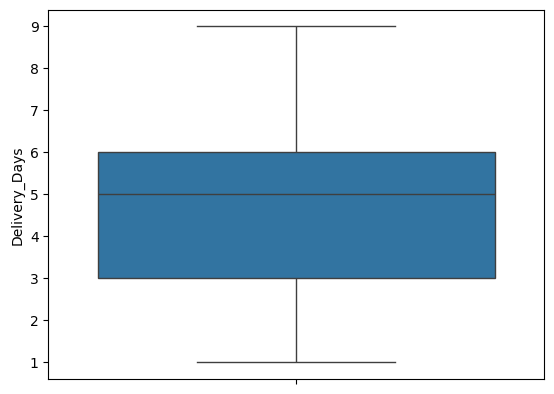

In [ ]:
sns.histplot(df6['Order_Value'], bins=15)
plt.title('Order Value Distribution')
plt.show()

sns.boxplot(y='Delivery_Days', data=df6)
plt.show()

### Exercise 7: Weather Analysis

In [ ]:
np.random.seed(7)
n = 50
df7 = pd.DataFrame({
    'City': np.random.choice(['Delhi','Mumbai','Chennai','Kolkata','Jaipur'], n),
    'Temperature': np.random.randint(15, 45, n),
    'Humidity': np.random.randint(30, 90, n),
    'Rainfall': np.random.randint(0, 200, n),
    'WindSpeed': np.random.randint(2, 30, n)
})

In [ ]:
avg_temp = df7['Temperature'].to_numpy().mean()
max_rain = df7['Rainfall'].to_numpy().max()
avg_humidity = df7['Humidity'].to_numpy().mean()

In [ ]:
city_avg = df7.groupby('City').mean(numeric_only=True)
hottest_city = city_avg['Temperature'].idxmax()
wettest_city = city_avg['Rainfall'].idxmax()

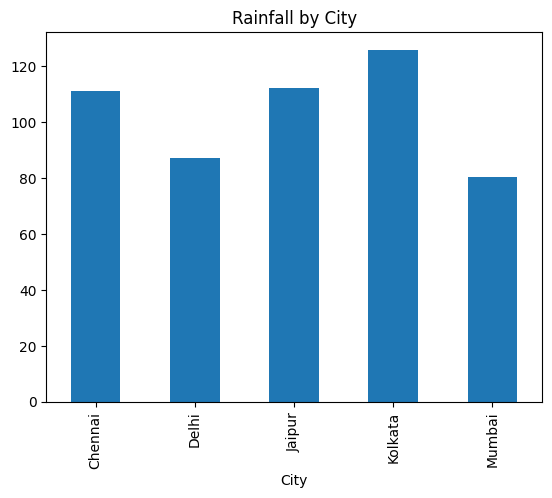

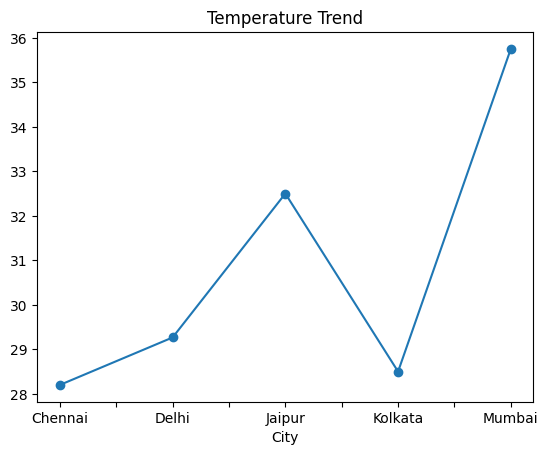

In [ ]:
city_avg['Rainfall'].plot(kind='bar')
plt.title('Rainfall by City')
plt.show()

city_avg['Temperature'].plot(kind='line', marker='o')
plt.title('Temperature Trend')
plt.show()

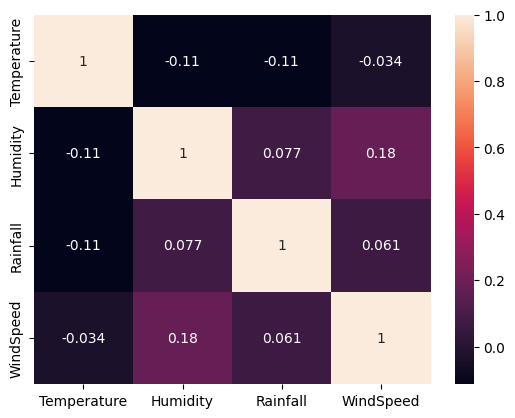

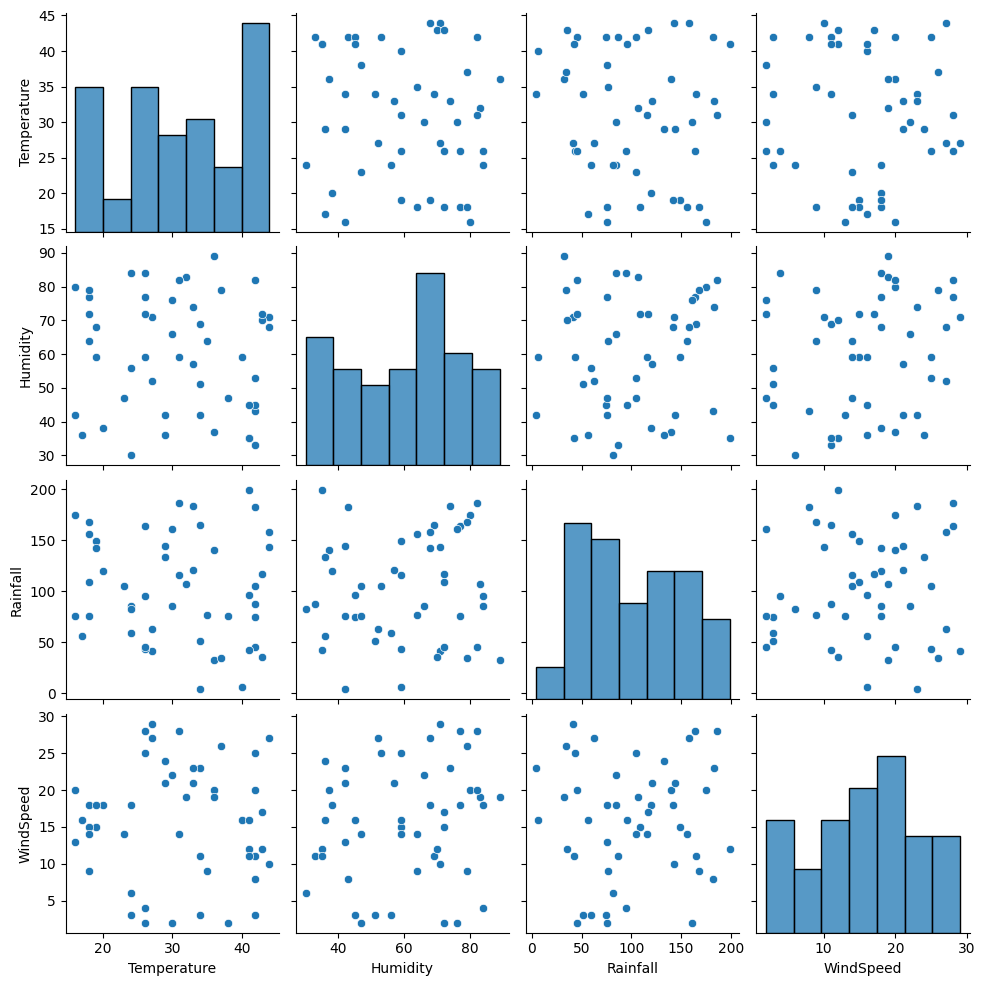

In [ ]:
sns.heatmap(df7[['Temperature','Humidity','Rainfall','WindSpeed']].corr(), annot=True)
plt.show()

sns.pairplot(df7[['Temperature','Humidity','Rainfall','WindSpeed']])
plt.show()